# Báo cáo Tổng quan Phân tích Chất lượng nước (Water Potability)

## 1. Mục tiêu
- **Mục tiêu chính**: Phân tích, khám phá (EDA) và xây dựng mô hình học máy để dự đoán chất lượng nước (nước có uống được hay không) dựa trên các chỉ số hóa lý.
- Giúp người đọc/ứng dụng tự động đánh giá mức độ an toàn của nguồn nước, từ đó đưa ra quyết định xử lý phù hợp.

## 2. Mô tả dữ liệu
Bộ dữ liệu cung cấp thông tin về các mẫu nước, với các thuộc tính:
- **ph**: Độ pH của nước (1-14).
- **Hardness**: Độ cứng của nước trong mg/L.
- **Solids**: Tổng lượng chất rắn hòa tan (TDS) trong mg/L.
- **Chloramines**: Lượng Chloramines (ppm).
- **Sulfate**: Lượng Sulfate hòa tan (mg/L).
- **Conductivity**: Độ dẫn điện (μS/cm).
- **Organic_carbon**: Lượng Cacbon hữu cơ (ppm).
- **Trihalomethanes**: Lượng Trihalomethanes (μg/L).
- **Turbidity**: Độ đục (NTU).
- **Potability**: Cột nhãn, 1 biểu thị nước an toàn để uống (Potable) và 0 là không an toàn.

---
## 3. Khám phá & Tiền xử lý dữ liệu (EDA)
### 3.1. Tải và xem cấu trúc dữ liệu

In [2]:
#Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
df = pd.read_csv('data/water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### 3.2. Kiểm tra dữ liệu bị thiếu (Missing Values)

In [4]:
print(f"Số dòng của dữ liệu:{len(df)}")
print(f"Số tổng missing mỗi cột:\n{df.isnull().sum()}")


Số dòng của dữ liệu:3276
Số tổng missing mỗi cột:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### 3.3. Xử lý dữ liệu bị thiếu
Do dữ liệu bị thiếu ở một lượng tương đối ở một số cột, ta sử dụng trung vị (median) để điền vào các giá trị bị thiếu (imputation) để tránh ảnh hưởng của outliers nhỏ/lớn so với giá trị trung bình (mean).

In [5]:
#Xử lý missing values bằng median
df_clean = df.fillna(df.median())
print(df_clean.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
df_clean.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [8]:
df_clean.corr()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000000,0.075760,-0.082004,-0.031741,0.014178,0.017466,0.040240,0.003145,-0.036107,-0.003014
Hardness,0.075760,1.000000,-0.046899,-0.030054,-0.092833,-0.023915,0.003610,-0.012707,-0.014449,-0.013837
Solids,-0.082004,-0.046899,1.000000,-0.070148,-0.149747,0.013831,0.010242,-0.008799,0.019546,0.033743
Chloramines,-0.031741,-0.030054,-0.070148,1.000000,0.023762,-0.020486,-0.012653,0.016614,0.002363,0.023779
Sulfate,0.014178,-0.092833,-0.149747,0.023762,1.000000,-0.014182,0.027102,-0.025657,-0.009767,-0.020476
Conductivity,0.017466,-0.023915,0.013831,-0.020486,-0.014182,1.000000,0.020966,0.001184,0.005798,-0.008128
Organic_carbon,0.040240,0.003610,0.010242,-0.012653,0.027102,0.020966,1.000000,-0.012958,-0.027308,-0.030001
Trihalomethanes,0.003145,-0.012707,-0.008799,0.016614,-0.025657,0.001184,-0.012958,1.000000,-0.021487,0.006887
Turbidity,-0.036107,-0.014449,0.019546,0.002363,-0.009767,0.005798,-0.027308,-0.021487,1.000000,0.001581
Potability,-0.003014,-0.013837,0.033743,0.023779,-0.020476,-0.008128,-0.030001,0.006887,0.001581,1.000000


### 3.4. Trực quan hóa dữ liệu (Data Visualization)
Sử dụng các biểu đồ (histogram, heatmap, boxplot) để hiểu rõ hơn về phân phối của từng đặc trưng và mối tương quan (correlation) giữa chúng.

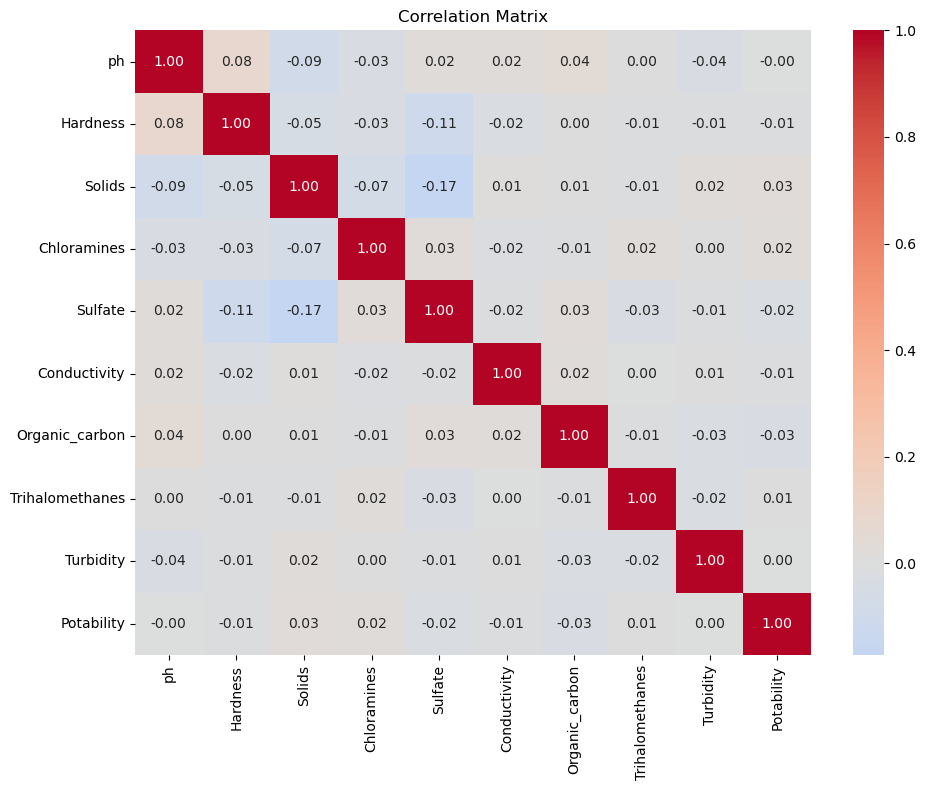

In [ ]:
#Biểu đồ heatmap tương quan giữa các feature
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

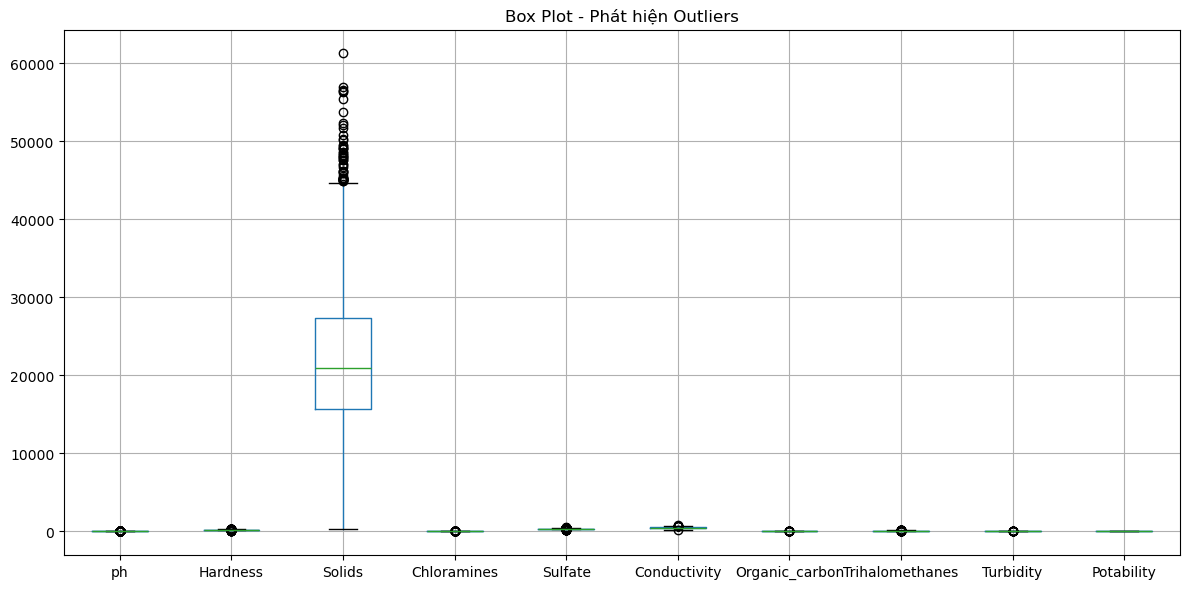

In [27]:
# Cách tìm các điểm outlier
# Visualize bằng box plot
plt.figure(figsize=(12, 6))
df_clean.boxplot()
plt.title('Box Plot - Phát hiện Outliers')
plt.tight_layout()
plt.show()

Tiến hành xử lý Outliers bằng phương pháp Capping (Winsorization)...
Hoàn tất xử lý Outliers! Vẽ lại Boxplot để kiểm chứng:


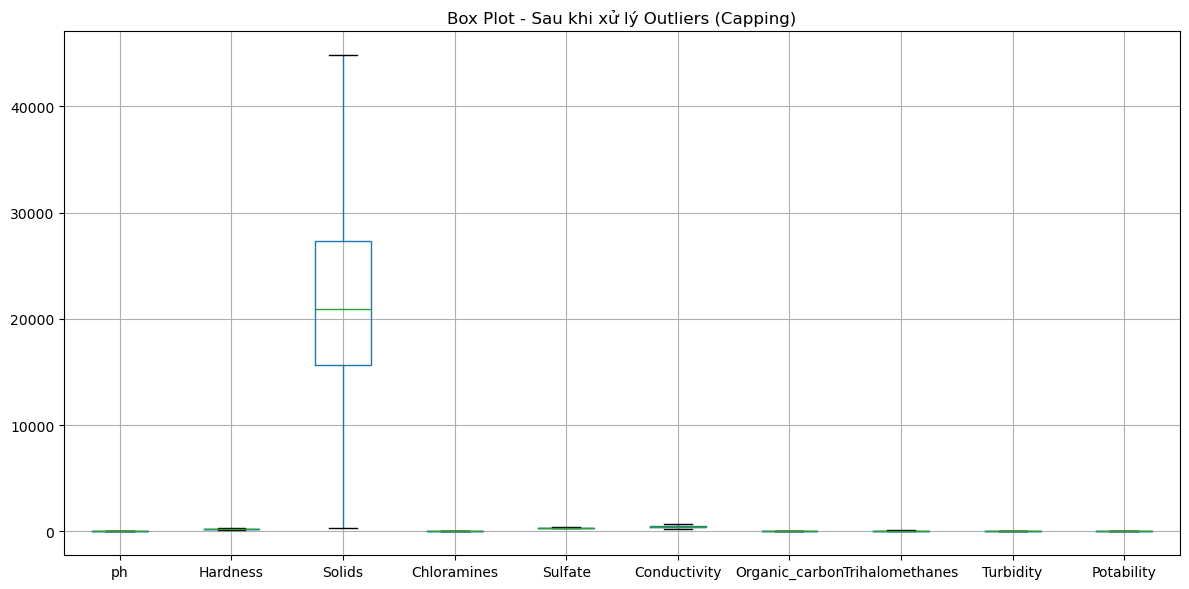

In [9]:
# Xử lý Outliers bằng phương pháp Capping (giới hạn theo phân vị IQR) 
# Việc này giúp giảm tác động của Outliers mà không bị mất số lượng dòng dữ liệu
print("Tiến hành xử lý Outliers bằng phương pháp Capping (Winsorization)...")

df_clean_no_outliers = df_clean.copy()
num_cols = df_clean_no_outliers.columns.drop('Potability')

for col in num_cols:
    Q1 = df_clean_no_outliers[col].quantile(0.25)
    Q3 = df_clean_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Áp dụng Capping
    df_clean_no_outliers[col] = np.where(df_clean_no_outliers[col] < lower_bound, lower_bound, df_clean_no_outliers[col])
    df_clean_no_outliers[col] = np.where(df_clean_no_outliers[col] > upper_bound, upper_bound, df_clean_no_outliers[col])

print("Hoàn tất xử lý Outliers! Vẽ lại Boxplot để kiểm chứng:")
plt.figure(figsize=(12, 6))
df_clean_no_outliers.boxplot()
plt.title('Box Plot - Sau khi xử lý Outliers (Capping)')
plt.tight_layout()
plt.show()

# Cập nhật lại df_clean để các cell phía dưới (Chuẩn hóa, Huấn luyện mô hình...) dùng dữ liệu đã sạch
df_clean = df_clean_no_outliers

In [10]:
from scipy import stats

# Skewness của từng cột
skewness = df_clean.skew()
print("Skewness của từng cột:")
print(skewness)

# Giải thích:
# Skewness > 0.5: Right-skewed (lệch phải)
# Skewness < -0.5: Left-skewed (lệch trái)
# -0.5 to 0.5: Gần đối xứng

Skewness của từng cột:
ph                 0.054541
Hardness          -0.024977
Solids             0.484566
Chloramines       -0.017865
Sulfate            0.055554
Conductivity       0.240572
Organic_carbon     0.008749
Trihalomethanes   -0.051791
Turbidity         -0.014413
Potability         0.450784
dtype: float64


<Figure size 1400x600 with 0 Axes>

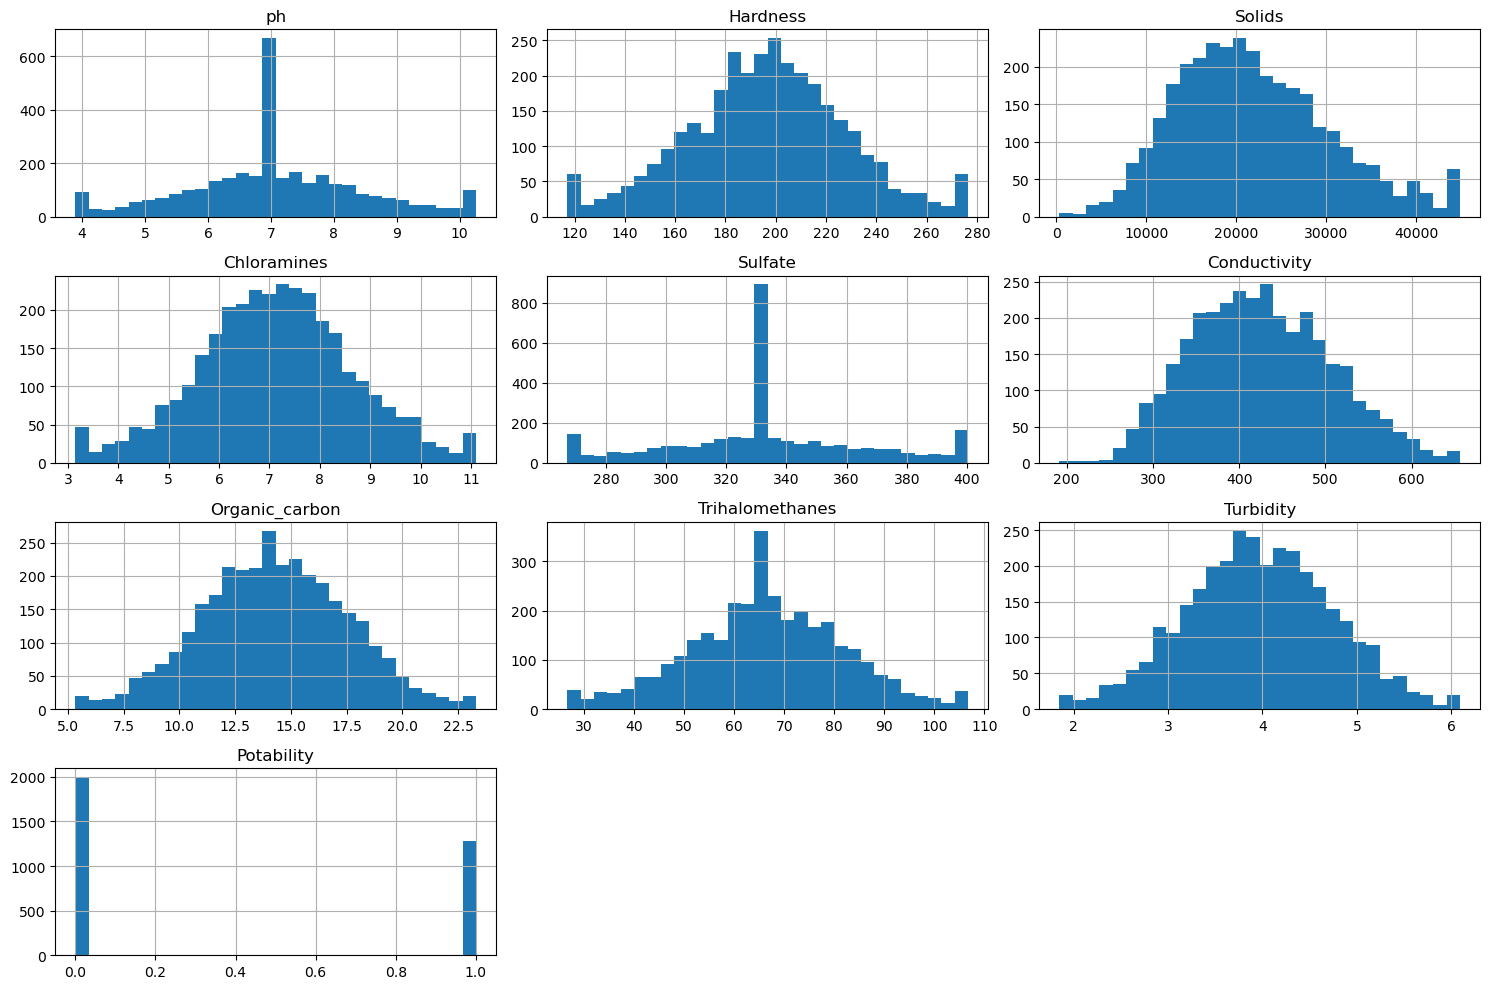

In [11]:
plt.figure(figsize=(14, 6))
df_clean.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [12]:
print("Distribution of Potability:")
print(df_clean['Potability'].value_counts())
print("\nPercentage:")
print(df_clean['Potability'].value_counts(normalize=True) * 100)

Distribution of Potability:
Potability
0    1998
1    1278
Name: count, dtype: int64

Percentage:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


### 3.5. Chuẩn hóa dữ liệu (Data Scaling)
Các features trong data có các thang đo rất khác nhau (ví dụ: Hardness vs Solids). Việc sử dụng các mô hình học máy yêu cầu dữ liệu phải ở cùng một thang đo để tránh việc ưu tiên cho feature nào có giá trị lớn. Ta thực hiện StandardScaler.

In [13]:
# Chuẩn hoá dữ liệu
from sklearn.preprocessing import StandardScaler

# Tách X (features) và y (target)
X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled data:")
print(X_scaled.head())
print(f"\nMean: {X_scaled.mean()}")
print(f"Std: {X_scaled.std()}")

Scaled data:
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0 -0.026484  0.265461 -0.135691     0.115564  1.098554      1.715401   
1 -2.304373 -2.091993 -0.387249    -0.315144 -0.017243      2.070162   
2  0.742334  0.869786 -0.238325     1.395235 -0.017243     -0.093403   
3  0.899837  0.561689  0.007136     0.607257  0.732414     -0.780410   
4  1.461021 -0.477657 -0.463030    -0.372561 -0.739361     -0.344116   

   Organic_carbon  Trihalomethanes  Turbidity  
0       -1.187299         1.327709  -1.292657  
1        0.272685        -0.652415   0.687944  
2        0.786278        -0.000744  -1.173116  
3        1.263149         2.189888   0.852978  
4       -0.828861        -2.223698   0.139720  

Mean: ph                -2.505119e-16
Hardness          -1.507409e-16
Solids            -2.271958e-16
Chloramines       -2.776235e-16
Sulfate            7.287618e-16
Conductivity      -9.353527e-16
Organic_carbon     1.735147e-17
Trihalomethanes   -5.769364e-16
Tur

### 3.6. Kiểm định giả thuyết (Hypothesis Testing) & Độ phân quan trọng của Feature
Tiến hành kiểm định giả thuyết Pearson Correlation để xem mối tương quan giữa các đặc trưng có ý nghĩa thống kê hay không, từ đó giúp chọn lọc feature cho mô hình.

In [14]:
from scipy.stats import pearsonr

# Tính correlation coefficient và p-value
corr_coef, p_value = pearsonr(df_clean['ph'], df_clean['Solids'])

print("Hypothesis Testing: pH vs Solids")
print("="*50)
print(f"Null Hypothesis: Increase in pH is associated with increase in Solids")
print(f"Alternate: No relation between pH and Solids")
print("="*50)
print(f"Correlation Coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.6f}")
print("="*50)

# Kết luận
alpha = 0.05
if p_value < alpha:
    print(f"✓ P-value ({p_value:.6f}) < {alpha}")
    print("→ Reject Null Hypothesis")
    print("→ Có mối quan hệ có ý nghĩa thống kê giữa pH và Solids")
else:
    print(f"✗ P-value ({p_value:.6f}) >= {alpha}")
    print("→ Fail to Reject Null Hypothesis")
    print("→ Không có mối quan hệ có ý nghĩa thống kê giữa pH và Solids")

Hypothesis Testing: pH vs Solids
Null Hypothesis: Increase in pH is associated with increase in Solids
Alternate: No relation between pH and Solids
Correlation Coefficient: -0.0780
P-value: 0.000008
✓ P-value (0.000008) < 0.05
→ Reject Null Hypothesis
→ Có mối quan hệ có ý nghĩa thống kê giữa pH và Solids


Feature Importance (Correlation with Potability):
Potability         1.000000
Solids             0.031847
Chloramines        0.023523
Trihalomethanes    0.006818
Turbidity          0.001597
ph                -0.001683
Conductivity      -0.007881
Hardness          -0.013360
Sulfate           -0.015506
Organic_carbon    -0.029282
Name: Potability, dtype: float64


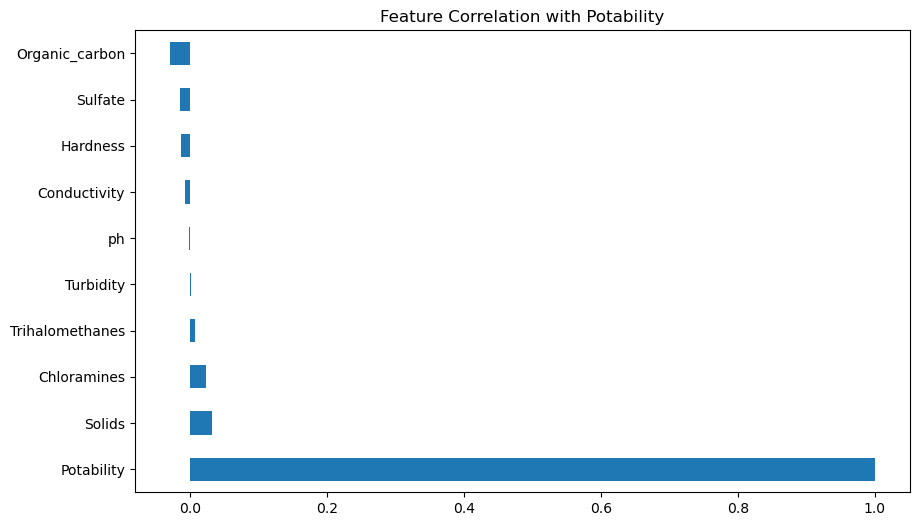

In [15]:
# Xem feature nào quan trọng nhất với Potability
corr_target = df_clean.corr()['Potability'].sort_values(ascending=False)
print("Feature Importance (Correlation with Potability):")
print(corr_target)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
corr_target.plot(kind='barh')
plt.title('Feature Correlation with Potability')
plt.show()

## 4. Xây dựng và Huấn luyện mô hình cơ sở (Baseline Models)
Lý do chọn mô hình:
- **Logistic Regression**: Thích hợp làm base model cho các bài toán phân loại nhị phân. Đơn giản, dễ giải thích.
- **Random Forest**: Xử lý tốt các feature phi tuyến tính và có khả năng giải quyết nhiễu (noise) / outliers còn sót lại từ EDA. (Giả sử ta dùng RF/Logistic Regression)

In [16]:
from sklearn.model_selection import train_test_split

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Giữ tỉ lệ class như dataset gốc
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTrain class distribution: \n{y_train.value_counts()}")
print(f"\nTest class distribution: \n{y_test.value_counts()}")

Training set size: 2620
Test set size: 656

Train class distribution: 
Potability
0    1598
1    1022
Name: count, dtype: int64

Test class distribution: 
Potability
0    400
1    256
Name: count, dtype: int64


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Xây dựng model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Dự đoán
y_pred_lr = lr_model.predict(X_test)

# Đánh giá
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression Results:
Accuracy: 0.6098
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


c:\Users\ADMIN\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

Random Forest Results:
Accuracy: 0.6585
Precision: 0.6250
Recall: 0.3125
F1-Score: 0.4167

Feature Importance:
           Feature  Importance
0               ph    0.129775
4          Sulfate    0.122014
3      Chloramines    0.119320
1         Hardness    0.118030
2           Solids    0.115380
5     Conductivity    0.102696
6   Organic_carbon    0.101049
8        Turbidity    0.097453
7  Trihalomethanes    0.094283


## 5. Kết luận (Insights & Next Steps)
### 5.1. Insights (Kết quả rút ra)
- Quá trình khám phá dữ liệu (EDA) cho thấy hầu hết các thông số lý hóa của nước đều có phân phối gần chuẩn, tuy nhiên chúng có các scale lớn nhỏ khác biệt.
- Correlation heatmap chỉ ra rằng mối liên kết tuyến tính (linear correlation) giữa từng biến cụ thể và tỷ lệ nước uống được (Potability) là khá yếu -> Không có "Silver bullet" (một biến nào quyết định mọi thứ). Việc dùng một mô hình tuyến tính có thể khó đạt độ chính xác cao nhất.
- Sau khi đào tạo, đánh giá mô hình thể hiện mức độ khả thi của việc dự đoán dựa án học máy.

### 5.2. Next Steps (Hướng đi tiếp theo)
- **Feature Engineering:** Kết hợp/tạo biến mới hoặc sử dụng các phép biến đổi logarit cho các biến có phân phối lệch (skewed).
- **Hyperparameter Tuning:** Sử dụng GridSearchCV hoặc RandomSearchCV tối ưu các tham số của các mô hình phi tuyến mạnh hơn như Gradient Boosting, XGBoost, LightGBM,...
- **Xử lý bất cân bằng nhãn (nếu có):** Dùng kĩ thuật Oversampling/SMOTE nếu bộ dữ liệu chênh lệch quá mức giữa nhãn 1 và nhãn 0.